# Image-to-Text Model Pipeline Test

In this notebook we will be testing the full end to end Image-to-Text Model pipeline to ensure that it is ready to be used in our final application.

The pipeline will be executed in the following format:

1. Present an image of a note containing multiple lines of writing
2. Pass the image into preprocessing pipleine so that it can be input into first layer
3. **First Layer**: Passing image into a text detector (CRAFT or OpenCV) to isolate lines of text
4. Preprocess sentences to format useable for TROCR model
5. **Second Layer**: Run TROCR model and present results.

We will be using [Chinmays18/medical-perscription-dataset](https://huggingface.co/datasets/chinmays18/medical-prescription-dataset) as it gives us access to full synthetic perscriptions that we can use to test the models capabilities on full word document images.



## Imports and Installs

In [18]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from datasets import load_dataset
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    ViTImageProcessor,
    RobertaTokenizer
)

# Set device for Apple Silicon (MPS) or CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


## Loading the Finetuned Image-to-text Model

In [19]:
MODEL_PATH = "../models/trocr_final_mdl"

# Fallback to base model if checkpoints haven't been exported yet
if not os.path.exists(MODEL_PATH):
    print(f"Custom model path '{MODEL_PATH}' not found. Loading base checkpoint for demonstration...")
    MODEL_PATH = "microsoft/trocr-base-handwritten"

image_processor = ViTImageProcessor.from_pretrained(MODEL_PATH)
tokenizer = RobertaTokenizer.from_pretrained(MODEL_PATH, use_fast=False)
processor = TrOCRProcessor(image_processor=image_processor, tokenizer=tokenizer)

model = VisionEncoderDecoderModel.from_pretrained(MODEL_PATH).to(device)
model.eval()

print("TrOCR pipeline loaded successfully!")

Loading weights: 100%|██████████| 480/480 [00:00<00:00, 7919.35it/s]


TrOCR pipeline loaded successfully!


In [ ]:
def segment_lines_advanced(image: Image.Image, min_area=300):
    """
    Advanced line segmentation using vertical projection profiling
    and contour filtering to isolate clean handwriting lines.
    """
    img_np = np.array(image.convert("RGB"))
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    
    # Contrast enhancement & adaptive binarization
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    thresh = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY_INV, 15, 8
    )

    # Refined horizontal morphological dilation
    # Keeps individual text lines connected while avoiding cross-line merging
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 2))
    dilated = cv2.dilate(thresh, kernel, iterations=2)

    # Extract bounding contours
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    boxes = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if w * h >= min_area and h >= 12 and w >= 25:
            boxes.append((x, y, w, h))
            
    # Sort top-to-bottom
    boxes = sorted(boxes, key=lambda b: b[1])
    
    line_crops = []
    annotated_img = img_np.copy()
    
    for (x, y, w, h) in boxes:
        # Add dynamic padding
        pad_y = max(0, y - 6)
        pad_h = min(img_np.shape[0] - pad_y, h + 12)
        pad_x = max(0, x - 6)
        pad_w = min(img_np.shape[1] - pad_x, w + 12)
        
        crop_np = img_np[pad_y:pad_y + pad_h, pad_x:pad_x + pad_w]
        
        # Ensure crop is not purely white space
        if crop_np.size > 0:
            line_crops.append(Image.fromarray(crop_np))
            cv2.rectangle(annotated_img, (pad_x, pad_y), (pad_x + pad_w, pad_y + pad_h), (0, 180, 0), 2)
            
    return line_crops, annotated_img

In [34]:
def segment_words(image: Image.Image, min_area: int = 150):
    """
    Segments individual word-level bounding boxes instead of full text lines.
    Optimized for word-level fine-tuned TrOCR checkpoints.
    """
    img_np = np.array(image.convert("RGB"))
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    
    # Adaptive thresholding
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    thresh = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY_INV, 15, 8
    )

    # Use a smaller horizontal kernel (12x2 or 8x2) to keep words separate
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (10, 2))
    dilated = cv2.dilate(thresh, kernel, iterations=2)

    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Extract bounding boxes
    boxes = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if w * h >= min_area and h >= 10 and w >= 15:
            boxes.append((x, y, w, h))
            
    # Sort boxes in standard reading order (line-by-line: top-to-bottom, left-to-right)
    def sort_reading_order(b_list, line_threshold=18):
        # Sort primarily by Y
        b_sorted = sorted(b_list, key=lambda b: b[1])
        lines = []
        current_line = []
        last_y = -1
        
        for b in b_sorted:
            if last_y == -1 or abs(b[1] - last_y) < line_threshold:
                current_line.append(b)
                last_y = b[1]
            else:
                lines.append(sorted(current_line, key=lambda b: b[0]))
                current_line = [b]
                last_y = b[1]
        if current_line:
            lines.append(sorted(current_line, key=lambda b: b[0]))
            
        return [box for line in lines for box in line]

    sorted_boxes = sort_reading_order(boxes)
    
    word_crops = []
    annotated_img = img_np.copy()
    
    for (x, y, w, h) in sorted_boxes:
        pad_y = max(0, y - 4)
        pad_h = min(img_np.shape[0] - pad_y, h + 8)
        pad_x = max(0, x - 4)
        pad_w = min(img_np.shape[1] - pad_x, w + 8)
        
        crop_np = img_np[pad_y:pad_y + pad_h, pad_x:pad_x + pad_w]
        if crop_np.size > 0:
            word_crops.append(Image.fromarray(crop_np))
            cv2.rectangle(annotated_img, (pad_x, pad_y), (pad_x + pad_w, pad_y + pad_h), (0, 180, 0), 2)
            
    return word_crops, annotated_img

In [21]:
def recognize_text_lines(line_crops):
    """
    Runs TrOCR with repetition penalties and beam search to avoid hallucinated character loops.
    """
    recognized_lines = []

    for crop in line_crops:
        # Preprocess visual tensor
        pixel_values = processor(crop, return_tensors="pt").pixel_values.to(device)

        with torch.no_grad():
            # Constrained generation
            generated_ids = model.generate(
                pixel_values,
                max_new_tokens=40,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=3,
                repetition_penalty=1.5,
                length_penalty=1.0
            )

        pred_text = processor.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
        cleaned_text = pred_text.strip()
        
        # Filter out empty or low-confidence single-character artifacts
        if len(cleaned_text) > 1:
            recognized_lines.append(cleaned_text)

    return recognized_lines

In [35]:
def recognize_text_words(word_crops):
    """
    Recognizes individual word crops and reconstructs the full prescription string.
    """
    extracted_words = []

    for crop in word_crops:
        # Preprocess visual tensor
        pixel_values = processor(crop, return_tensors="pt").pixel_values.to(device)

        with torch.no_grad():
            # Constrained generation
            generated_ids = model.generate(
                pixel_values,
                max_new_tokens=40,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=3,
                repetition_penalty=1.5,
                length_penalty=1.0
            )

        word_text = processor.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
        
        # Filter out empty or low-confidence single-character artifacts
        if len(word_text) > 0 and word_text not in ["<s>", "</s>", "<pad>"]:
            extracted_words.append(word_text)

    return extracted_words

## Loading the Test Image

In [38]:
test_image_path = "../data/test_images"
test_image_file = "test_img_1.jpg"
test_image = os.path.join(test_image_path, test_image_file)

# 1. Load local prescription image and matching JSON annotation (if available)
print(f"Loading local prescription document: {test_image}")
sample_full_image = Image.open(test_image).convert("RGB")

Loading local prescription document: ../data/test_images/test_img_1.jpg


## Running the Model on the test Image

[transformers] Both `max_new_tokens` (=40) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Detected 4 clean line segments.


[transformers] Both `max_new_tokens` (=40) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=40) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=40) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


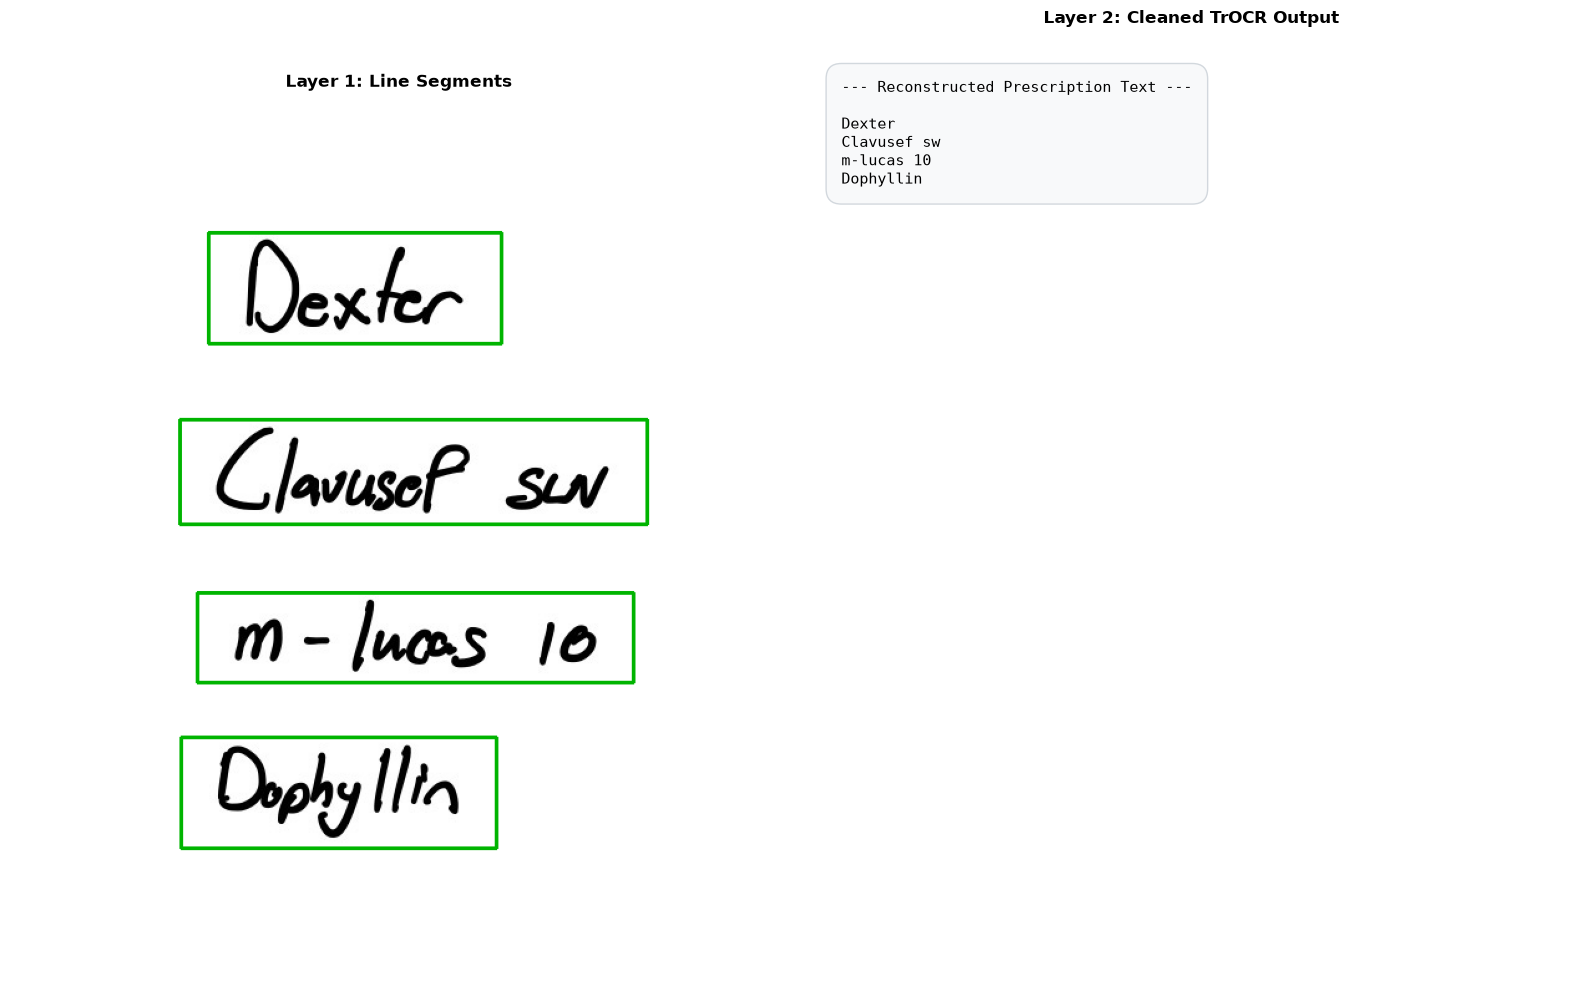


--- Final Recognized Text ---
Dexter
Clavusef sw
m-lucas 10
Dophyllin


In [41]:
# Attempt to load corresponding ground truth JSON
base_name = os.path.splitext(test_image_file_2)[0]
test_annotation_file = os.path.join(test_image_path_2, f"{base_name}.json")

if os.path.exists(test_annotation_file):
    with open(test_annotation_file, "r") as f:
        annotation_data = json.load(f)
    ground_truth_text = annotation_data.get("ground_truth", "No annotation key found.")
else:
    ground_truth_text = "Ground truth annotation file not found."

# 2. Layer 1: Detect and slice lines using advanced profiling

line_crops, annotated_canvas = segment_lines_advanced(sample_full_image_2)
print(f"Detected {len(line_crops)} clean line segments.")

# 2. Recognize text per slice
extracted_lines = recognize_text_lines(line_crops)
full_extracted_prescription = "\n".join(extracted_lines)

# 3. Diagnostic Plotting: Show full segmentation + each cropped line
fig = plt.figure(figsize=(16, 10))

# Left: Full annotated document
ax_main = plt.subplot2grid((max(len(line_crops), 4), 2), (0, 0), rowspan=max(len(line_crops), 4))
ax_main.imshow(annotated_canvas)
ax_main.set_title("Layer 1: Line Segments", fontsize=12, fontweight="bold")
ax_main.axis("off")

# Right: Text Summary Box
ax_text = plt.subplot2grid((max(len(line_crops), 4), 2), (0, 1), rowspan=max(len(line_crops), 4))
ax_text.text(
    0.05, 0.95,
    f"--- Reconstructed Prescription Text ---\n\n{full_extracted_prescription}",
    fontsize=11,
    verticalalignment="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=1", facecolor="#f8f9fa", edgecolor="#ced4da", alpha=0.9)
)
ax_text.set_title("Layer 2: Cleaned TrOCR Output", fontsize=12, fontweight="bold")
ax_text.axis("off")

plt.tight_layout()
plt.show()

print("\n--- Final Recognized Text ---")
print(full_extracted_prescription)

[transformers] Both `max_new_tokens` (=40) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Detected 7 clean line segments.


[transformers] Both `max_new_tokens` (=40) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=40) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=40) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=40) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

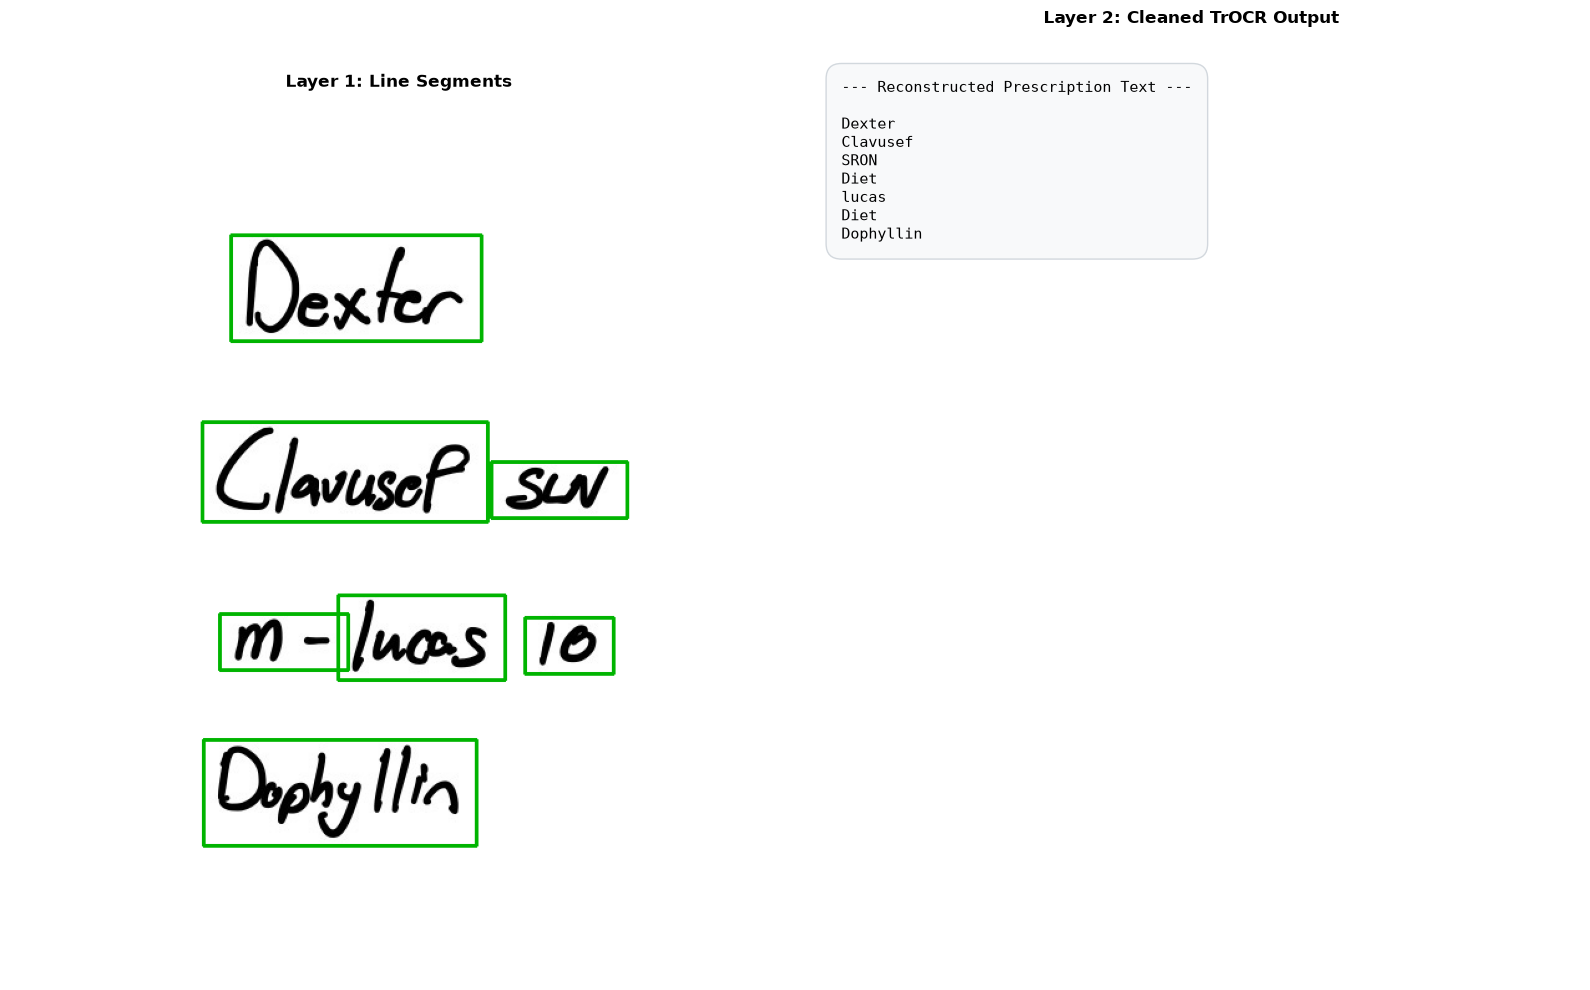


--- Final Recognized Text ---
Dexter
Clavusef
SRON
Diet
lucas
Diet
Dophyllin


In [ ]:
# Attempt to load corresponding ground truth JSON
base_name = os.path.splitext(test_image_file)[0]
test_annotation_file = os.path.join(test_image_path, f"{base_name}.json")

if os.path.exists(test_annotation_file):
    with open(test_annotation_file, "r") as f:
        annotation_data = json.load(f)
    ground_truth_text = annotation_data.get("ground_truth", "No annotation key found.")
else:
    ground_truth_text = "Ground truth annotation file not found."

# Layer 1: Detect and slice lines using advanced profiling

word_crops, annotated_canvas = segment_words(sample_full_image)
print(f"Detected {len(word_crops)} clean line segments.")

# Recognize text per slice
extracted_words = recognize_text_words(word_crops)
full_extracted_prescription = "\n".join(extracted_words)

# Diagnostic Plotting: Show full segmentation + each cropped line
fig = plt.figure(figsize=(16, 10))

# Left: Full annotated document
ax_main = plt.subplot2grid((max(len(word_crops), 4), 2), (0, 0), rowspan=max(len(word_crops), 4))
ax_main.imshow(annotated_canvas)
ax_main.set_title("Layer 1: Line Segments", fontsize=12, fontweight="bold")
ax_main.axis("off")

# Right: Text Summary Box
ax_text = plt.subplot2grid((max(len(word_crops), 4), 2), (0, 1), rowspan=max(len(word_crops), 4))
ax_text.text(
    0.05, 0.95,
    f"--- Reconstructed Prescription Text ---\n\n{full_extracted_prescription}",
    fontsize=11,
    verticalalignment="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=1", facecolor="#f8f9fa", edgecolor="#ced4da", alpha=0.9)
)
ax_text.set_title("Layer 2: Cleaned TrOCR Output", fontsize=12, fontweight="bold")
ax_text.axis("off")

plt.tight_layout()
plt.show()

print("\n--- Final Recognized Text ---")
print(full_extracted_prescription)

In [ ]:
test_image_path_2 = "../data/test_images"
test_image_file_2 = "test_img_2.jpg"
test_image_2 = os.path.join(test_image_path_2, test_image_file_2)

# Load local prescription image and matching JSON annotation (if available)
print(f"Loading local prescription document: {test_image_2}")
sample_full_image_2 = Image.open(test_image_2).convert("RGB")

Loading local prescription document: ../data/test_images/test_img_2.jpg


[transformers] Both `max_new_tokens` (=40) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Detected 28 clean line segments.


[transformers] Both `max_new_tokens` (=40) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=40) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=40) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=40) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

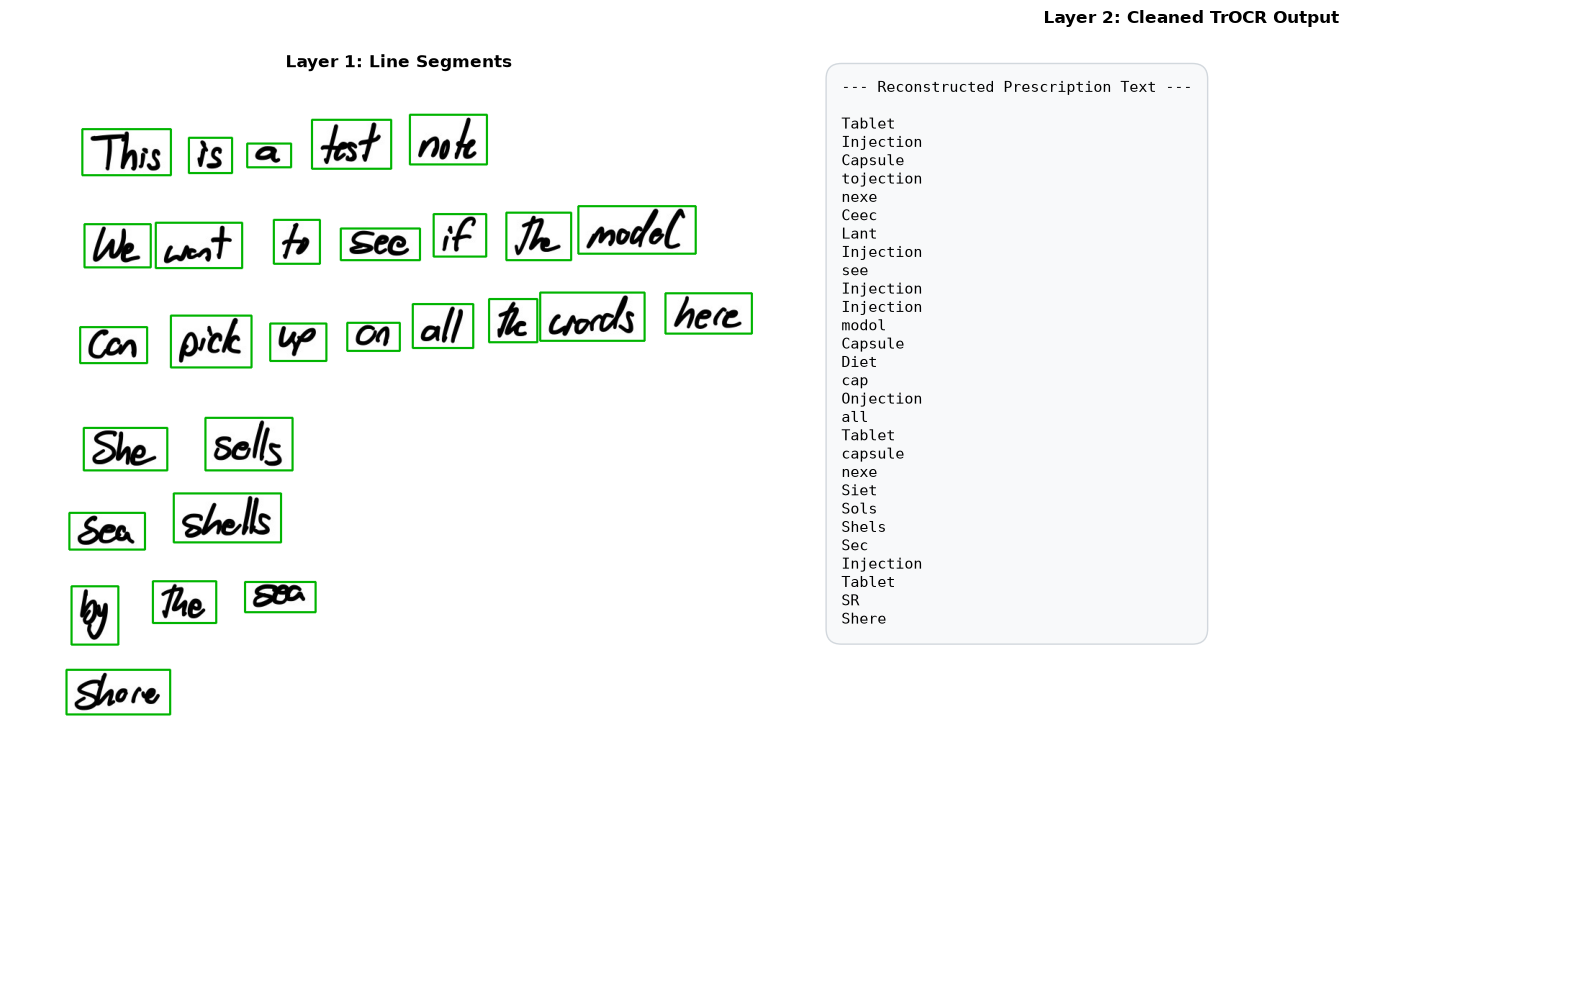


--- Final Recognized Text ---
Tablet
Injection
Capsule
tojection
nexe
Ceec
Lant
Injection
see
Injection
Injection
modol
Capsule
Diet
cap
Onjection
all
Tablet
capsule
nexe
Siet
Sols
Shels
Sec
Injection
Tablet
SR
Shere


In [ ]:
# Attempt to load corresponding ground truth JSON
base_name = os.path.splitext(test_image_file_2)[0]
test_annotation_file_2 = os.path.join(test_image_path_2, f"{base_name}.json")

if os.path.exists(test_annotation_file_2):
    with open(test_annotation_file_2, "r") as f:
        annotation_data = json.load(f)
    ground_truth_text = annotation_data.get("ground_truth", "No annotation key found.")
else:
    ground_truth_text = "Ground truth annotation file not found."

# Layer 1: Detect and slice lines using advanced profiling

word_crops, annotated_canvas = segment_words(sample_full_image_2)
print(f"Detected {len(word_crops)} clean line segments.")

# Recognize text per slice
extracted_words = recognize_text_words(word_crops)
full_extracted_prescription = "\n".join(extracted_words)

# 3. Diagnostic Plotting: Show full segmentation + each cropped line
fig = plt.figure(figsize=(16, 10))

# Left: Full annotated document
ax_main = plt.subplot2grid((max(len(word_crops), 4), 2), (0, 0), rowspan=max(len(word_crops), 4))
ax_main.imshow(annotated_canvas)
ax_main.set_title("Layer 1: Line Segments", fontsize=12, fontweight="bold")
ax_main.axis("off")

# Right: Text Summary Box
ax_text = plt.subplot2grid((max(len(word_crops), 4), 2), (0, 1), rowspan=max(len(word_crops), 4))
ax_text.text(
    0.05, 0.95,
    f"--- Reconstructed Prescription Text ---\n\n{full_extracted_prescription}",
    fontsize=11,
    verticalalignment="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=1", facecolor="#f8f9fa", edgecolor="#ced4da", alpha=0.9)
)
ax_text.set_title("Layer 2: Cleaned TrOCR Output", fontsize=12, fontweight="bold")
ax_text.axis("off")

plt.tight_layout()
plt.show()

print("\n--- Final Recognized Text ---")
print(full_extracted_prescription)

So it appears that with training the model on perscription data it seems to be calibrated to only be able to detect those kind of words so lets try running the baseline model to see if it makes any difference and gives us the output that we want

In [49]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Baseline checkpoint: 'microsoft/trocr-base-handwritten' or 'microsoft/trocr-base-printed'
BASELINE_MODEL_ID = "microsoft/trocr-base-handwritten"

# Load processor and model directly from Hugging Face hub
base_image_processor = ViTImageProcessor.from_pretrained(BASELINE_MODEL_ID)
base_tokenizer = RobertaTokenizer.from_pretrained(BASELINE_MODEL_ID, use_fast=False)
base_processor = TrOCRProcessor(image_processor=base_image_processor, tokenizer=base_tokenizer)

base_model = VisionEncoderDecoderModel.from_pretrained(BASELINE_MODEL_ID).to(device)
base_model.eval()

print("Baseline TrOCR pipeline loaded successfully!")

Loading weights: 100%|██████████| 478/478 [00:00<00:00, 7130.58it/s]
[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Baseline TrOCR pipeline loaded successfully!


In [50]:
def baseline_recognize_text_words(word_crops):
    """
    Recognizes individual word crops and reconstructs the full prescription string.
    """
    extracted_words = []

    for crop in word_crops:
        # Preprocess visual tensor
        pixel_values = processor(crop, return_tensors="pt").pixel_values.to(device)

        with torch.no_grad():
            # Constrained generation
            generated_ids = base_model.generate(
                pixel_values,
                max_new_tokens=40,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=3,
                repetition_penalty=1.5,
                length_penalty=1.0
            )

        word_text = base_processor.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
        
        # Filter out empty or low-confidence single-character artifacts
        if len(word_text) > 0 and word_text not in ["<s>", "</s>", "<pad>"]:
            extracted_words.append(word_text)

    return extracted_words

Detected 28 clean line segments.


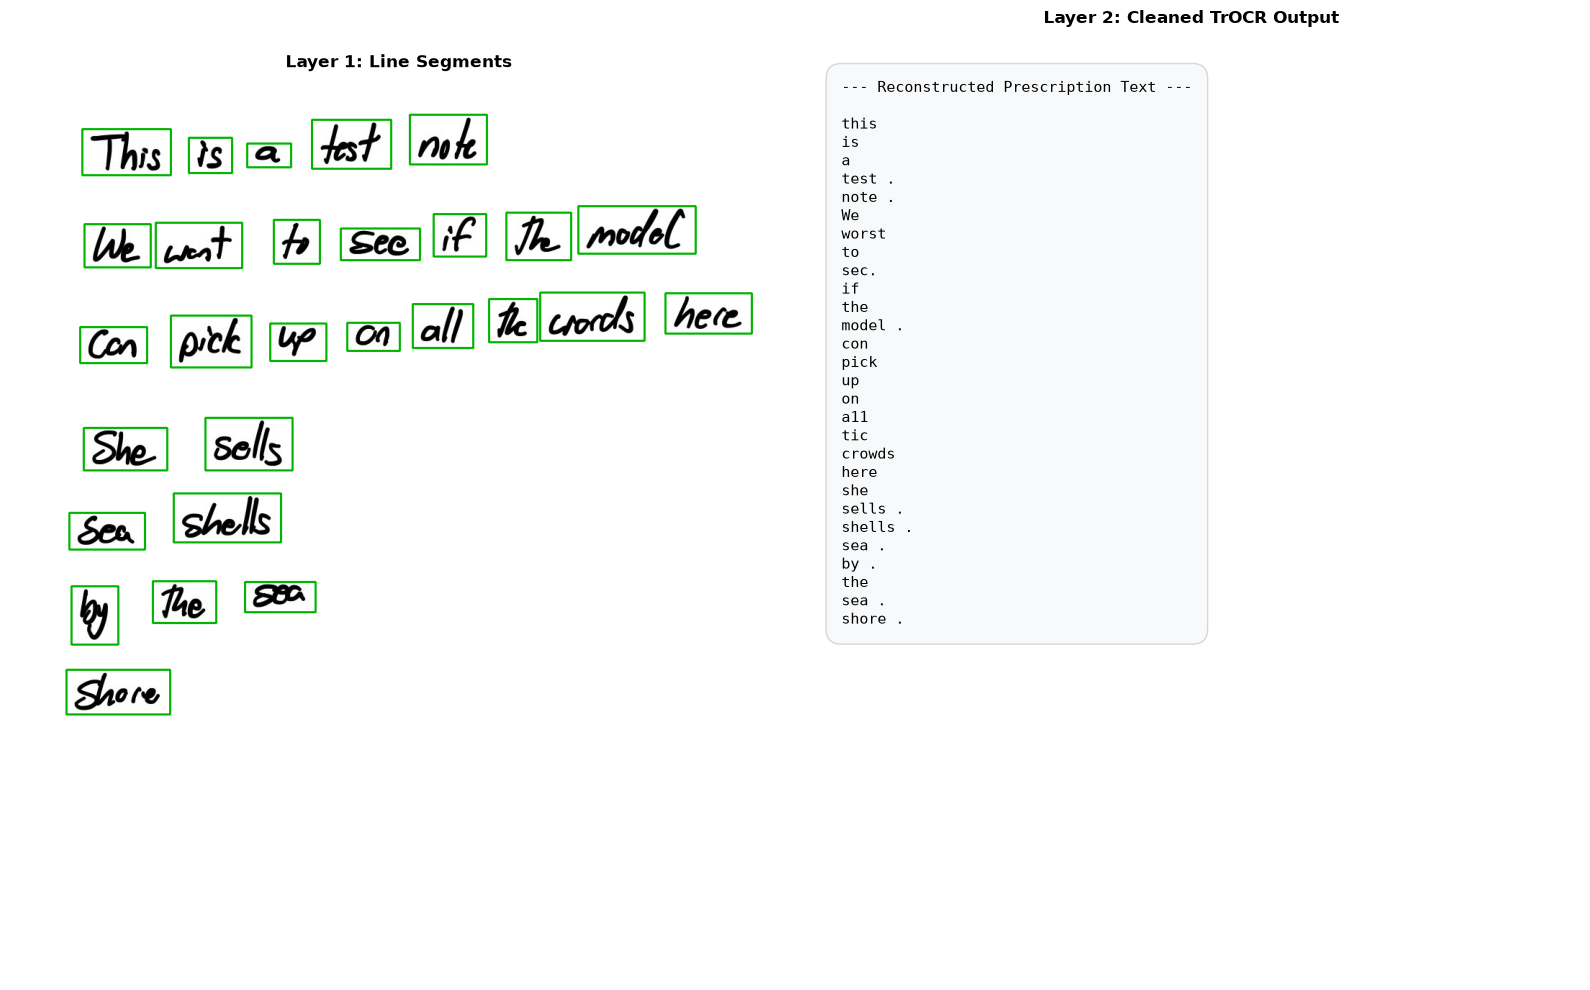


--- Final Recognized Text ---
this
is
a
test .
note .
We
worst
to
sec.
if
the
model .
con
pick
up
on
a11
tic
crowds
here
she
sells .
shells .
sea .
by .
the
sea .
shore .


In [51]:
# Attempt to load corresponding ground truth JSON
base_name = os.path.splitext(test_image_file_2)[0]
test_annotation_file_2 = os.path.join(test_image_path_2, f"{base_name}.json")

if os.path.exists(test_annotation_file_2):
    with open(test_annotation_file_2, "r") as f:
        annotation_data = json.load(f)
    ground_truth_text = annotation_data.get("ground_truth", "No annotation key found.")
else:
    ground_truth_text = "Ground truth annotation file not found."

# 2. Layer 1: Detect and slice lines using advanced profiling

word_crops, annotated_canvas = segment_words(sample_full_image_2)
print(f"Detected {len(word_crops)} clean line segments.")

# 2. Recognize text per slice
extracted_words = baseline_recognize_text_words(word_crops)
full_extracted_prescription = "\n".join(extracted_words)

# 3. Diagnostic Plotting: Show full segmentation + each cropped line
fig = plt.figure(figsize=(16, 10))

# Left: Full annotated document
ax_main = plt.subplot2grid((max(len(word_crops), 4), 2), (0, 0), rowspan=max(len(word_crops), 4))
ax_main.imshow(annotated_canvas)
ax_main.set_title("Layer 1: Line Segments", fontsize=12, fontweight="bold")
ax_main.axis("off")

# Right: Text Summary Box
ax_text = plt.subplot2grid((max(len(word_crops), 4), 2), (0, 1), rowspan=max(len(word_crops), 4))
ax_text.text(
    0.05, 0.95,
    f"--- Reconstructed Prescription Text ---\n\n{full_extracted_prescription}",
    fontsize=11,
    verticalalignment="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=1", facecolor="#f8f9fa", edgecolor="#ced4da", alpha=0.9)
)
ax_text.set_title("Layer 2: Cleaned TrOCR Output", fontsize=12, fontweight="bold")
ax_text.axis("off")

plt.tight_layout()
plt.show()

print("\n--- Final Recognized Text ---")
print(full_extracted_prescription)